# Getting started: your first SuperMAGE model

In this tutorial you will build a complete forward model of a rotating gas disk
in an early-type galaxy — stellar mass profile, central supermassive black
hole, gas disk — and render it into a spectral cube, the fundamental data
product of radio/mm interferometry and integral-field spectroscopy.

Along the way you will meet the two ideas that organize all of SuperMAGE:

1. **Everything is a differentiable PyTorch module.** The whole chain from
   black-hole mass to spectral cube supports autograd, so gradients of any
   output with respect to any parameter are available for free.
2. **Models are [caskade](https://github.com/Ciela-Institute/caskade) modules.**
   Static configuration (grids, resolutions, device) goes into constructors;
   physical *parameters* are `caskade.Param` objects that you supply at call
   time as a flat tensor — exactly what optimizers and samplers want.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import colors

from supermage.simulators.intensity_models import ExponentialDisk2D
from supermage.simulators.velocity_models import SersicMGE
from supermage.simulators.analytic_cube import AnalyticInverse
from supermage.utils.doppler_velocities import create_velocity_grid_stable
from supermage.utils.plotting import velocity_map

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
print(f"Running on {device}")

Running on cuda


## 1. The observational setup: a frequency axis

Interferometers observe spectral *channels* in frequency. We model 40 channels
around the CO(2–1) line at 230.538 GHz, spanning about ±400 km/s — enough to
contain the rotation of a massive galaxy.

```{important}
SuperMAGE's frequency-to-velocity conversion is **ratio-based**, so the
frequency axis and the rest-frame `line` frequency just need the *same
units*. The visibility simulators standardize on **Hz** and will refuse
values that look like GHz.
```

In [2]:
line_hz = 230.538e9         # CO(2-1) rest frequency [Hz]
c_kms   = 299792.458        # speed of light [km/s]

n_chan   = 40
span_kms = 800.0            # total velocity span of the band

df    = line_hz * (span_kms / c_kms) / (n_chan - 1)
freqs = line_hz + (np.arange(n_chan) - (n_chan - 1) / 2) * df   # ascending, [Hz]

velocities, dv = create_velocity_grid_stable(
    freqs[0], freqs[-1], n_chan, target_dtype=dtype, device=device, line=line_hz
)
print(f"channel width: {dv[0]:.2f} km/s;  "
      f"velocity range: [{velocities.min():.0f}, {velocities.max():.0f}] km/s")

channel width: -20.51 km/s;  velocity range: [-400, 400] km/s


## 2. The galaxy: intensity model + mass model

Two independent ingredients describe the disk:

- an **intensity model** — where the gas *is*. `ExponentialDisk2D` is a
  razor-thin exponential disk, `I(R) ∝ exp(−R/scale)`. Only the shape
  matters; total flux is calibrated separately.
- a **velocity (mass) model** — how fast it *rotates*. `SersicMGE` describes
  the stellar mass with a Sérsic profile that is converted on the fly to a
  Multi-Gaussian Expansion (MGE) whose circular velocity is computed
  exactly, plus a central black hole. See the
  [mass-models tutorial](02_mass_models.ipynb) for what happens inside.

In [3]:
distance_Mpc = 16.5
distance_pc  = distance_Mpc * 1e6

intensity_model = ExponentialDisk2D()
velocity_model  = SersicMGE(
    N_MGE_components=20,        # size of the Gaussian basis
    distance_Mpc=distance_Mpc,  # converts the profile's arcsec radii to pc
    soft=1.0,                   # BH softening length [pc]
    device=device, dtype=dtype,
)

## 3. The renderer

`AnalyticInverse` turns the two models into a spectral cube: it inverts the
disk projection pixel by pixel, evaluates intensity and line-of-sight
velocity, broadens each pixel into `K_vel` equal-flux Gaussian quantile
sub-channels, and box-filters an internally oversampled cube down to the
requested resolution.

The renderer *owns* the geometric parameters (inclination, position angle,
offsets…), and automatically links the velocity model's inclination to its
own, so the model has a single consistent inclination.

In [4]:
pixscale = 0.1   # arcsec / pixel
n_pix    = 101

sim = AnalyticInverse(
    intensity_model, velocity_model, freqs,
    pixel_scale_arcsec=pixscale, N_pix_x=n_pix,
    K_vel=8, oversamp_xy=4, oversamp_v=4,
    device=device, dtype=dtype, line=line_hz,
)

## 4. Parameters, the caskade way

Every `Param` in the module graph that has not been given a static value is
*dynamic*: it must be supplied when the model is called. `dynamic_params`
lists them in the exact order the flat parameter tensor must follow.

In [5]:
print([p.name for p in sim.dynamic_params])

['scale', 'qintr', 'm_bh', 'n', 'r_e', 'intensity_r_e', 'inclination', 'sky_rot', 'line_broadening', 'velocity_shift', 'x0', 'y0', 'distance_pc']


In [6]:
pars = {
    # intensity model
    "scale": 400.0,                     # exponential scale length [pc]
    # stellar mass model (Sersic -> MGE)
    "qintr": 0.6,                       # intrinsic axial ratio of the MGE
    "m_bh": 8.5,                        # log10(M_BH / M_sun)
    "n": 4.0,                           # Sersic index
    "r_e": 25.0,                        # effective radius [arcsec]
    "intensity_r_e": 2.8,               # log10 I(r_e)  (sets the mass scale)
    # geometry & kinematics
    "inclination": np.deg2rad(60.0),    # [rad]
    "sky_rot": np.deg2rad(30.0),        # [rad]
    "line_broadening": 10.0,            # gas velocity dispersion [km/s]
    "velocity_shift": 0.0,              # systemic velocity offset [km/s]
    "x0": 0.0, "y0": 0.0,               # sky offsets [arcsec]
    "distance_pc": distance_pc,
}
theta = torch.tensor([pars[p.name] for p in sim.dynamic_params],
                     device=device, dtype=dtype)

cube = sim.forward(theta)
print("cube shape (channels, y, x):", tuple(cube.shape))

cube shape (channels, y, x): (40, 101, 101)


## 5. Channel maps

Each channel shows the gas whose line-of-sight velocity Doppler-shifts it
into that frequency bin — the classic "butterfly" pattern of a rotating disk.

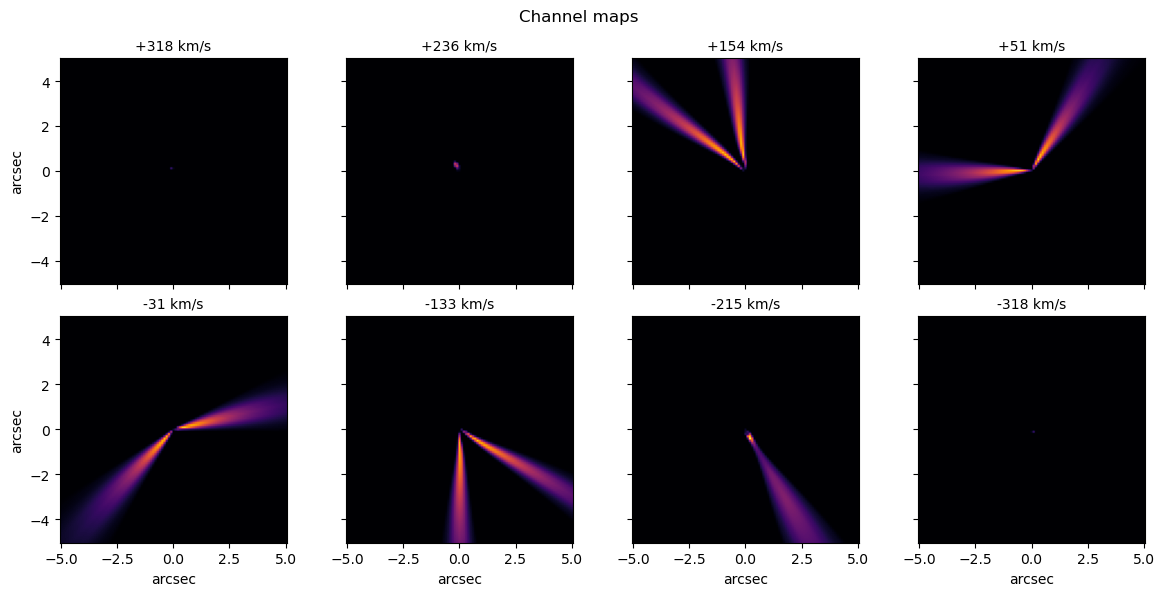

In [7]:
half_fov = pixscale * n_pix / 2
extent = (-half_fov, half_fov, -half_fov, half_fov)
vel_np = velocities.cpu().numpy()
cube_np = cube.detach().cpu().numpy()

chans = np.linspace(4, n_chan - 5, 8).astype(int)
fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=True, sharey=True)
vmax = cube_np.max()
for ax, ch in zip(axes.ravel(), chans):
    ax.imshow(cube_np[ch], origin="lower", cmap="inferno",
              extent=extent, vmin=0, vmax=vmax)
    ax.set_title(f"{vel_np[ch] - vel_np.mean():+.0f} km/s", fontsize=10)
for ax in axes[-1]:
    ax.set_xlabel("arcsec")
for ax in axes[:, 0]:
    ax.set_ylabel("arcsec")
fig.suptitle("Channel maps")
plt.tight_layout()
plt.show()

## 6. Moment maps

The zeroth moment (total intensity) recovers the projected disk; the first
moment (intensity-weighted mean velocity) shows the rotation field. The
steep velocity gradient in the innermost pixels is the black hole's doing.

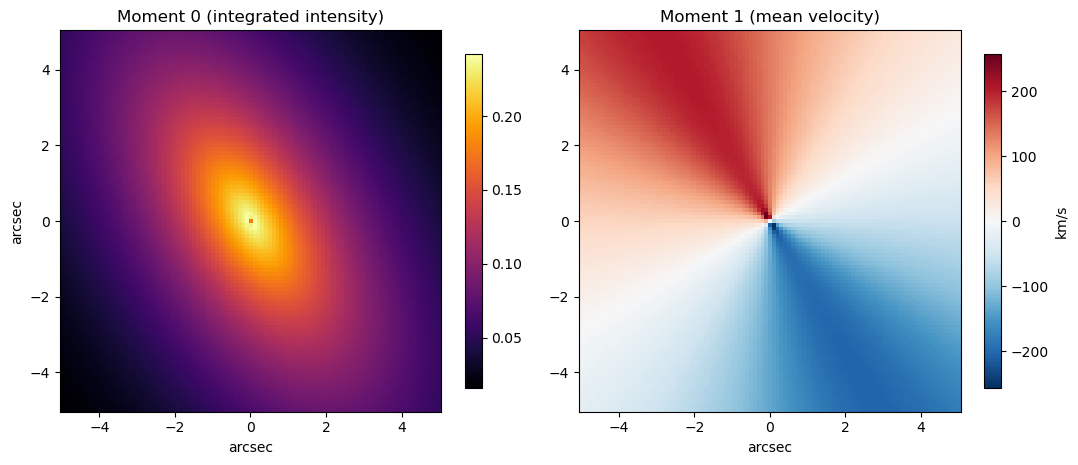

In [8]:
mom0 = cube_np.sum(axis=0)
# velocity_map expects the channel axis LAST
mom1 = velocity_map(np.moveaxis(cube_np, 0, -1), vel_np - vel_np.mean())

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = ax0.imshow(mom0, origin="lower", cmap="inferno", extent=extent)
ax0.set_title("Moment 0 (integrated intensity)")
fig.colorbar(im0, ax=ax0, shrink=0.85)

vext = np.nanmax(np.abs(mom1))
im1 = ax1.imshow(np.where(mom0 > 1e-4 * mom0.max(), mom1, np.nan),
                 origin="lower", cmap="RdBu_r", extent=extent,
                 norm=colors.TwoSlopeNorm(vcenter=0, vmin=-vext, vmax=vext))
ax1.set_title("Moment 1 (mean velocity)")
fig.colorbar(im1, ax=ax1, shrink=0.85, label="km/s")
for ax in (ax0, ax1):
    ax.set_xlabel("arcsec")
ax0.set_ylabel("arcsec")
plt.tight_layout()
plt.show()

## 7. The rotation curve behind the cube

Velocity models can be interrogated directly. Called on its own, `SersicMGE`
exposes its parameters under its *local* names (`inc` instead of the
renderer's `inclination`):

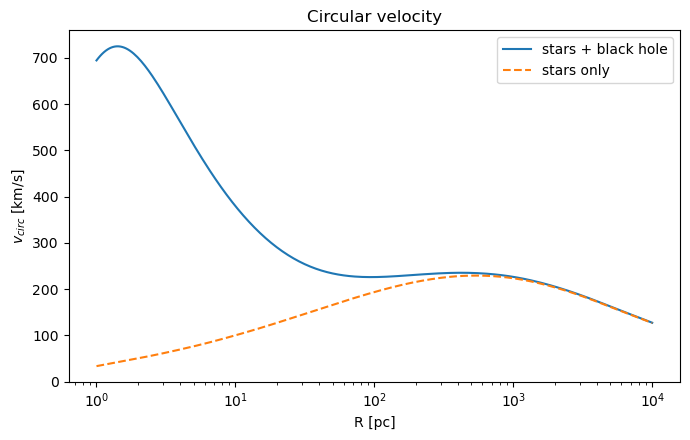

In [9]:
R = torch.logspace(0, 4, 300, device=device, dtype=dtype)   # 1 pc .. 10 kpc

theta_vel = torch.tensor(
    [pars["inclination"], pars["qintr"], pars["m_bh"],
     pars["n"], pars["r_e"], pars["intensity_r_e"]],
    device=device, dtype=dtype,
)
v_tot = velocity_model.velocity(theta_vel, R_flat=R)

theta_nobh = theta_vel.clone()
theta_nobh[2] = -10.0     # log10 M_BH -> effectively zero mass
v_stars = velocity_model.velocity(theta_nobh, R_flat=R)

R_np = R.cpu().numpy()
plt.figure(figsize=(7, 4.5))
plt.plot(R_np, v_tot.detach().cpu(), label="stars + black hole")
plt.plot(R_np, v_stars.detach().cpu(), "--", label="stars only")
plt.xscale("log")
plt.xlabel("R [pc]")
plt.ylabel("$v_{circ}$ [km/s]")
plt.title("Circular velocity")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Differentiability: gradients through the whole chain

Because every step is built from differentiable Torch ops, autograd can
propagate through projection, quadrature, quantile broadening and binning.
Here is the gradient of the central-pixel spectrum's peak with respect to
*all thirteen* model parameters, from one backward pass:

In [10]:
theta_g = theta.clone().requires_grad_(True)
cube_g = sim.forward(theta_g)
peak_central = cube_g[:, n_pix // 2, n_pix // 2].max()
(grad,) = torch.autograd.grad(peak_central, theta_g)

for p, g in zip(sim.dynamic_params, grad):
    print(f"d(peak)/d({p.name:15s}) = {g.item():+.3e}")

d(peak)/d(scale          ) = +8.350e-07
d(peak)/d(qintr          ) = +2.601e-04
d(peak)/d(m_bh           ) = +5.363e-02
d(peak)/d(n              ) = +1.144e-03
d(peak)/d(r_e            ) = +8.770e-06
d(peak)/d(intensity_r_e  ) = +2.188e-03
d(peak)/d(inclination    ) = -9.194e-02
d(peak)/d(sky_rot        ) = +8.629e-02
d(peak)/d(line_broadening) = -1.086e-03
d(peak)/d(velocity_shift ) = +1.123e-03
d(peak)/d(x0             ) = +1.987e+00
d(peak)/d(y0             ) = -4.724e+00
d(peak)/d(distance_pc    ) = -1.296e-09


This is what powers everything in the [fitting tutorial](05_fitting_mock_data.ipynb):
Levenberg–Marquardt with exact Jacobians, and gradient-based MCMC.

## Where to go next

- [Mass models and rotation curves](02_mass_models.ipynb) — the MGE engine,
  Sérsic/Nuker/Core-Sérsic profiles, composite mass models.
- [Cloud-based simulation](03_cloud_catalog.ipynb) — the Monte-Carlo
  KinMS-style renderer.
- [Visibilities](04_visibilities.ipynb) — from cubes to interferometer data.
- [Fitting mock data](05_fitting_mock_data.ipynb) — end-to-end inference.
- [Lensed cubes](06_lensed_cubes.ipynb) — kinematics through a
  gravitational lens.